In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported")


Libraries imported


In [14]:
df = pd.read_csv(r"C:\Users\lohith\Downloads\archive (1)\AI-based Career Recommendation System.csv")
print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (200, 8)


,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,1,John Doe,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,2,Jane Smith,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,3,Bob Johnson,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88
3,4,Emily Davis,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,AI Researcher,0.93
4,5,Michael Brown,30,Master's,Project Management;Communication;Agile,Business;Management,Project Manager,0.87
5,6,Sarah Wilson,27,Bachelor's,C++;Embedded Systems;IoT,Electronics;Automation,Embedded Systems Engineer,0.91
6,7,David Lee,35,Master's,SQL;Data Warehousing;ETL,Finance;Analytics,Data Analyst,0.89
7,8,Laura Martinez,29,Bachelor's,Content Writing;SEO;Social Media,Marketing;Communications,Digital Marketer,0.86
8,9,Kevin White,31,Bachelor's,Python;Natural Language Processing;Machine Lea...,Linguistics;Technology,NLP Engineer,0.92
9,10,Karen Thompson,33,Master's,Financial Analysis;Excel;Econometrics,Finance;Data Analysis,Financial Analyst,0.90


In [15]:
print("Column info:")
print(df.dtypes)
print()
print(f"Unique careers: {df['Recommended_Career'].nunique()}")
print(f"Unique education levels: {df['Education'].unique().tolist()}")
print(f"Age range: {df['Age'].min()}–{df['Age'].max()}")


Column info:
CandidateID               int64
Name                     object
Age                       int64
Education                object
Skills                   object
Interests                object
Recommended_Career       object
Recommendation_Score    float64
dtype: object

Unique careers: 32
Unique education levels: ["Bachelor's", "Master's", 'PhD']
Age range: 22–41


In [16]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate CandidateIDs: {df['CandidateID'].duplicated().sum()}")


Missing values per column:
CandidateID             0
Name                    0
Age                     0
Education               0
Skills                  0
Interests               0
Recommended_Career      0
Recommendation_Score    0
dtype: int64

Duplicate rows: 0
Duplicate CandidateIDs: 0


In [17]:
df['Skills_List'] = df['Skills'].str.split(';')
df['Interests_List'] = df['Interests'].str.split(';')

df['Skills_Clean'] = df['Skills'].str.replace(';', ' ').str.replace('-', '_').str.lower()
df['Interests_Clean'] = df['Interests'].str.replace(';', ' ').str.replace('-', '_').str.lower()
df['Profile_Text'] = df['Skills_Clean'] + ' ' + df['Interests_Clean']

df['Num_Skills'] = df['Skills_List'].apply(len)
df['Num_Interests'] = df['Interests_List'].apply(len)

print("Skills/Interests parsed into clean text profiles")
df[['Skills','Skills_Clean','Num_Skills']].head()


Skills/Interests parsed into clean text profiles


,Skills,Skills_Clean,Num_Skills
0,Python;Data Analysis;Machine Learning,python data analysis machine learning,3
1,Java;System Design;Cloud Computing,java system design cloud computing,3
2,Graphic Design;UI/UX;Adobe Creative Suite,graphic design ui/ux adobe creative suite,3
3,Python;Deep Learning;Statistics,python deep learning statistics,3
4,Project Management;Communication;Agile,project management communication agile,3


In [18]:
print("All 32 career labels:")
print(sorted(df['Recommended_Career'].unique()))


All 32 career labels:
['AI Researcher', 'AI Specialist', 'Automation Engineer', 'Backend Developer', 'Biostatistician', 'Business Analyst', 'Cloud Engineer', 'Content Strategist', 'Cybersecurity Analyst', 'Cybersecurity Specialist', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'Deep Learning Engineer', 'DevOps Engineer', 'Digital Marketer', 'Embedded Systems Engineer', 'Financial Analyst', 'Front-end Developer', 'Full Stack Developer', 'Graphic Designer', 'Machine Learning Engineer', 'Marketing Manager', 'Mobile Developer', 'NLP Engineer', 'Project Manager', 'Research Analyst', 'Research Scientist', 'Software Developer', 'Software Engineer', 'UX Designer', 'UX Researcher']


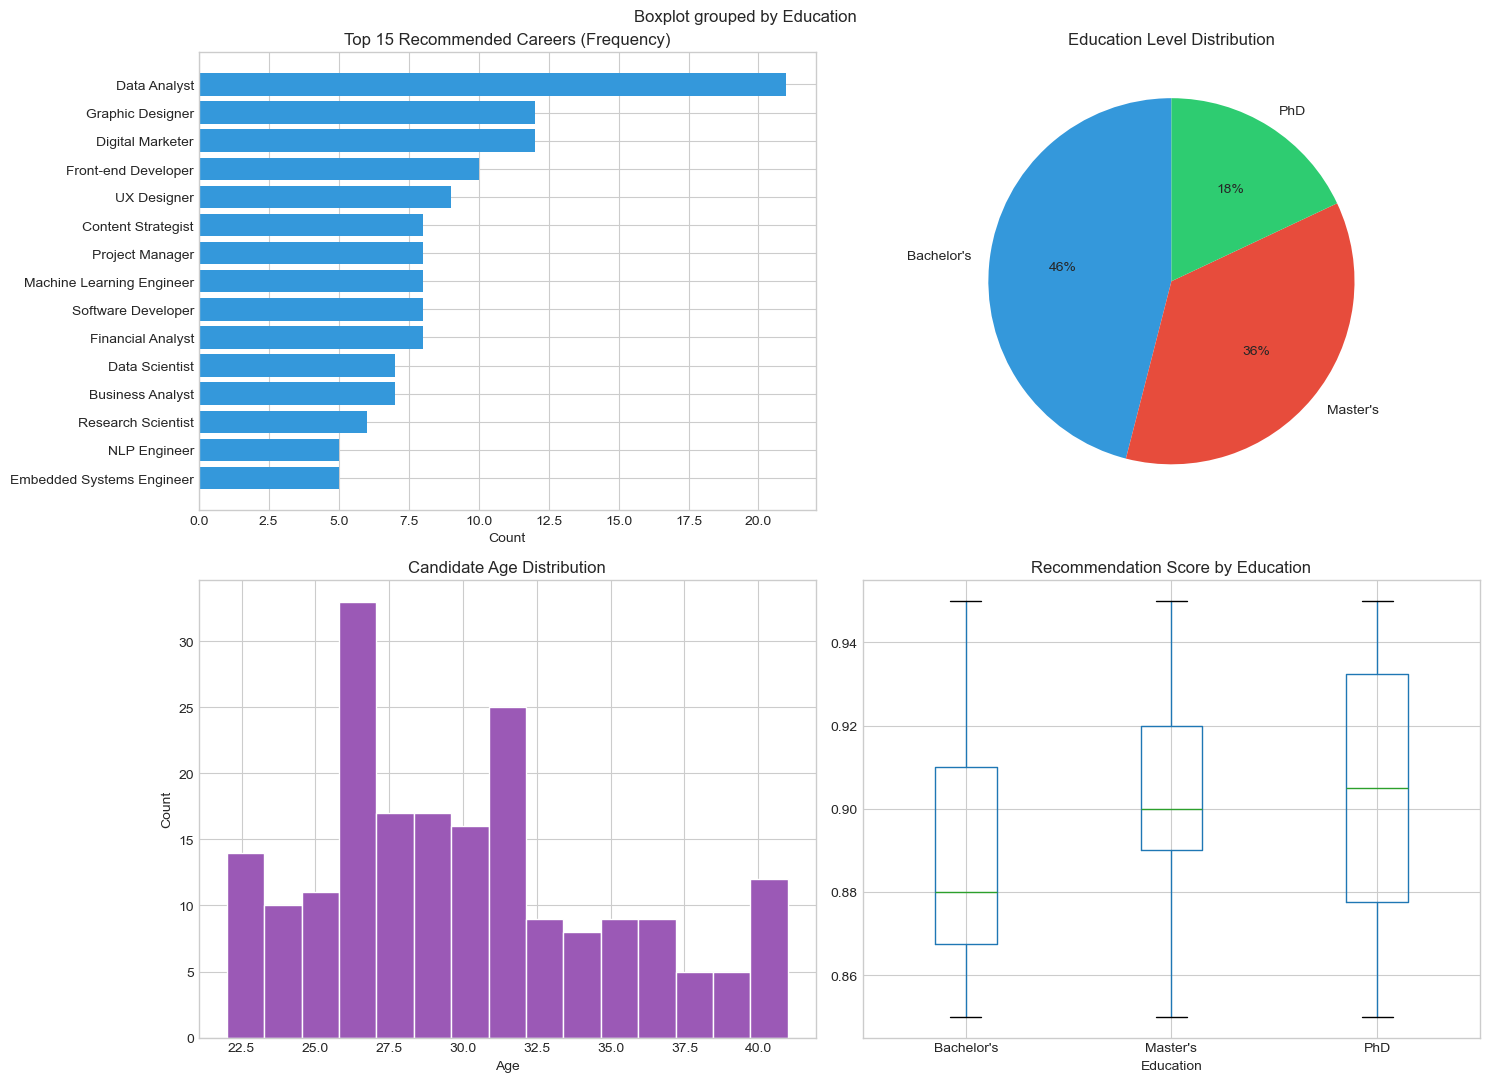

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('AI Career Recommendation Dataset — EDA', fontsize=16, fontweight='bold')

top_careers = df['Recommended_Career'].value_counts().head(15)
axes[0,0].barh(top_careers.index[::-1], top_careers.values[::-1], color='#3498db')
axes[0,0].set_title('Top 15 Recommended Careers (Frequency)')
axes[0,0].set_xlabel('Count')

edu_counts = df['Education'].value_counts()
axes[0,1].pie(edu_counts.values, labels=edu_counts.index, autopct='%1.0f%%',
              colors=['#3498db','#e74c3c','#2ecc71'], startangle=90)
axes[0,1].set_title('Education Level Distribution')

axes[1,0].hist(df['Age'], bins=15, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Candidate Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Count')

df.boxplot(column='Recommendation_Score', by='Education', ax=axes[1,1])
plt.sca(axes[1,1]); plt.title('Recommendation Score by Education')
axes[1,1].set_xlabel('Education')

plt.tight_layout()
plt.savefig('career_eda.png', dpi=120, bbox_inches='tight')
plt.show()


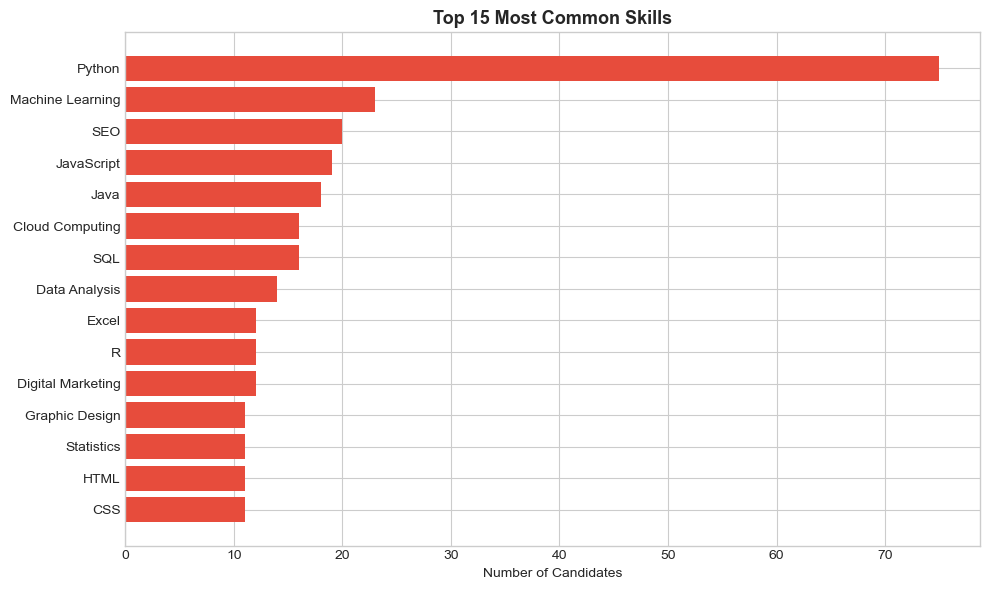

Total unique individual skills in dataset: 80


In [20]:
from collections import Counter
all_skills = [s.strip() for sub in df['Skills_List'] for s in sub]
skill_counts = Counter(all_skills).most_common(15)

fig, ax = plt.subplots(figsize=(10, 6))
skills, counts = zip(*skill_counts)
ax.barh(skills[::-1], counts[::-1], color='#e74c3c')
ax.set_title('Top 15 Most Common Skills', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Candidates')
plt.tight_layout()
plt.savefig('top_skills.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Total unique individual skills in dataset: {len(set(all_skills))}")


In [21]:
edu_order = {"Bachelor's": 1, "Master's": 2, 'PhD': 3}
df['Education_Level'] = df['Education'].map(edu_order)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['Profile_Text'])

print(f"Created Education_Level ordinal feature")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  ({tfidf_matrix.shape[1]} unique skill/interest terms)")
print(f"Num_Skills / Num_Interests count features created")


Created Education_Level ordinal feature
TF-IDF matrix shape: (200, 104)  (104 unique skill/interest terms)
Num_Skills / Num_Interests count features created


In [22]:
def recommend_careers_for_profile(skills_str, interests_str, top_n=5):
    """
    Given a free-text skills/interests profile, find the most similar
    candidates in the dataset (via TF-IDF cosine similarity) and return
    their recommended careers, ranked by similarity.
    """
    query_text = (skills_str.replace(';',' ') + ' ' + interests_str.replace(';',' ')).lower()
    query_vec = tfidf.transform([query_text])
    sims = cosine_similarity(query_vec, tfidf_matrix)[0]

    result = df.copy()
    result['Similarity'] = sims
    result = result.sort_values('Similarity', ascending=False)

    # Aggregate by career: average similarity + count of supporting candidates
    career_scores = (result.groupby('Recommended_Career')
                      .agg(Avg_Similarity=('Similarity','mean'),
                           Supporting_Candidates=('Similarity','count'))
                      .sort_values('Avg_Similarity', ascending=False))
    return career_scores.head(top_n)

test_skills = "Python;Machine Learning;Deep Learning"
test_interests = "Technology;AI"

print(f"Query profile  -> Skills: {test_skills} | Interests: {test_interests}\n")
print("Top career recommendations:")
recommend_careers_for_profile(test_skills, test_interests)


Query profile  -> Skills: Python;Machine Learning;Deep Learning | Interests: Technology;AI

Top career recommendations:


,Avg_Similarity,Supporting_Candidates
Recommended_Career,,
AI Researcher,0.378512,4
Machine Learning Engineer,0.359194,8
AI Specialist,0.341546,4
Data Engineer,0.267357,4
NLP Engineer,0.259970,5


In [23]:
test_skills2 = "Graphic Design;Adobe Creative Suite;Branding"
test_interests2 = "Arts;Digital Media"

print(f"Query profile  -> Skills: {test_skills2} | Interests: {test_interests2}\n")
recommend_careers_for_profile(test_skills2, test_interests2)


Query profile  -> Skills: Graphic Design;Adobe Creative Suite;Branding | Interests: Arts;Digital Media



,Avg_Similarity,Supporting_Candidates
Recommended_Career,,
UX Designer,0.334734,9
Biostatistician,0.309357,4
Full Stack Developer,0.309357,4
Graphic Designer,0.303338,12
Software Developer,0.193553,8


In [24]:
from scipy.sparse import hstack, csr_matrix

numeric_features = csr_matrix(df[['Age','Education_Level','Num_Skills','Num_Interests']].values)
X = hstack([tfidf_matrix, numeric_features])

le = LabelEncoder()
y = le.fit_transform(df['Recommended_Career'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Total features:   {X_train.shape[1]} (TF-IDF terms + 4 numeric)")
print(f"Number of career classes: {len(le.classes_)}")


Training samples: 150
Test samples:     50
Total features:   108 (TF-IDF terms + 4 numeric)
Number of career classes: 32


In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {'accuracy': acc, 'preds': preds, 'model': model}
    print(f"{name:22s} | Test Accuracy: {acc:.4f}")


Logistic Regression    | Test Accuracy: 0.2400
Random Forest          | Test Accuracy: 0.3600


In [26]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best = results[best_name]
print(f"🏆 Best Model: {best_name}  (Accuracy: {best['accuracy']:.4f})\n")

print("Classification Report:")
present_labels = sorted(set(y_test) | set(best['preds']))
present_names = le.inverse_transform(present_labels)
print(classification_report(y_test, best['preds'], labels=present_labels,
                             target_names=present_names, zero_division=0))


🏆 Best Model: Random Forest  (Accuracy: 0.3600)

Classification Report:
                           precision    recall  f1-score   support

      Automation Engineer       0.00      0.00      0.00         2
        Backend Developer       0.25      1.00      0.40         1
          Biostatistician       0.00      0.00      0.00         2
         Business Analyst       1.00      0.33      0.50         3
           Cloud Engineer       0.00      0.00      0.00         2
       Content Strategist       0.00      0.00      0.00         2
    Cybersecurity Analyst       0.00      0.00      0.00         4
             Data Analyst       0.00      0.00      0.00         5
            Data Engineer       0.00      0.00      0.00         0
           Data Scientist       1.00      0.50      0.67         2
   Deep Learning Engineer       0.00      0.00      0.00         1
          DevOps Engineer       0.00      0.00      0.00         0
         Digital Marketer       0.60      0.60      0.60

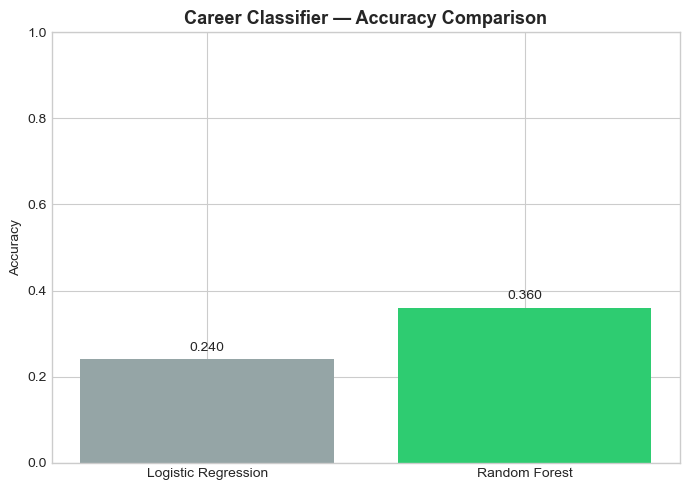

In [27]:
fig, ax = plt.subplots(figsize=(7,5))
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
colors = ['#2ecc71' if a==max(accs) else '#95a5a6' for a in accs]
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(0, 1)
ax.set_title('Career Classifier — Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, a in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.3f}', ha='center')
plt.tight_layout()
plt.savefig('career_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


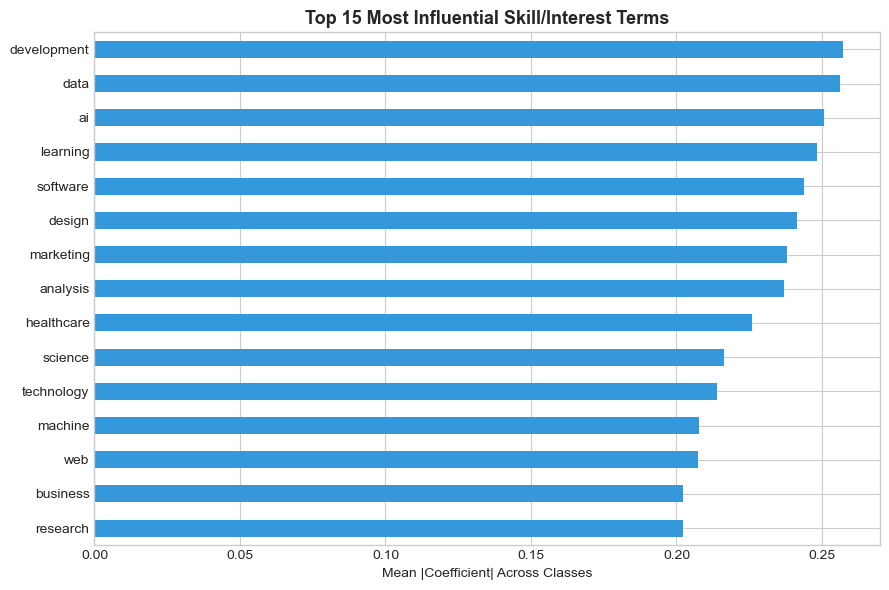

In [28]:
lr = results['Logistic Regression']['model']
feature_names = tfidf.get_feature_names_out()

coef_matrix = lr.coef_[:, :len(feature_names)]  # text-feature portion only
mean_abs_importance = np.abs(coef_matrix).mean(axis=0)
top_terms = pd.Series(mean_abs_importance, index=feature_names).nlargest(15)

fig, ax = plt.subplots(figsize=(9,6))
top_terms.sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 15 Most Influential Skill/Interest Terms', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |Coefficient| Across Classes')
plt.tight_layout()
plt.savefig('career_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [30]:
def skill_gap_for_recommendation(user_skills_str, top_career_row):
    """Compare a user's skills against the most common skills of candidates
    who were recommended the top matching career."""
    career = top_career_row.name
    matching_candidates = df[df['Recommended_Career'] == career]
    career_skill_pool = Counter(
        s.strip() for sub in matching_candidates['Skills_List'] for s in sub
    )
    user_set = set(s.strip() for s in user_skills_str.split(';'))
    common_skills = [s for s,_ in career_skill_pool.most_common(8)]
    missing = [s for s in common_skills if s not in user_set]
    return career, missing

test_skills = "Python;Machine Learning;Deep Learning"
test_interests = "Technology;AI"
recs = recommend_careers_for_profile(test_skills, test_interests, top_n=1)
career, missing_skills = skill_gap_for_recommendation(test_skills, recs.iloc[0])

print(f"Top recommended career: {career}")
print(f"Your skills: {test_skills}")
print(f"Commonly required skills you don't have yet: {missing_skills if missing_skills else 'None — strong match!'}")


Top recommended career: AI Researcher
Your skills: Python;Machine Learning;Deep Learning
Commonly required skills you don't have yet: ['Statistics', 'HTML', 'CSS', 'JavaScript', 'Java', 'Algorithms']
